In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'autompg-dataset' dataset.
Path to dataset files: /kaggle/input/autompg-dataset


<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 30.6+ KB
None
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0   

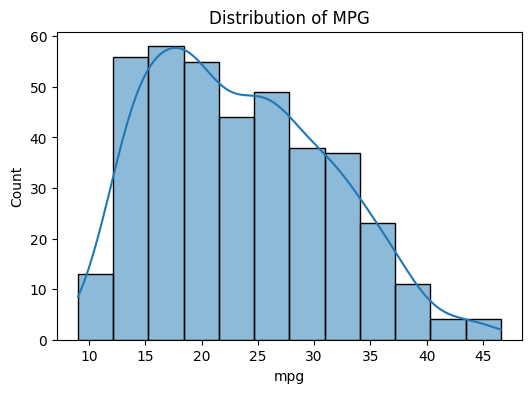

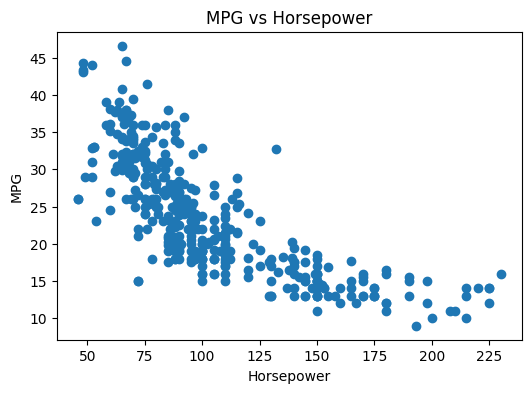

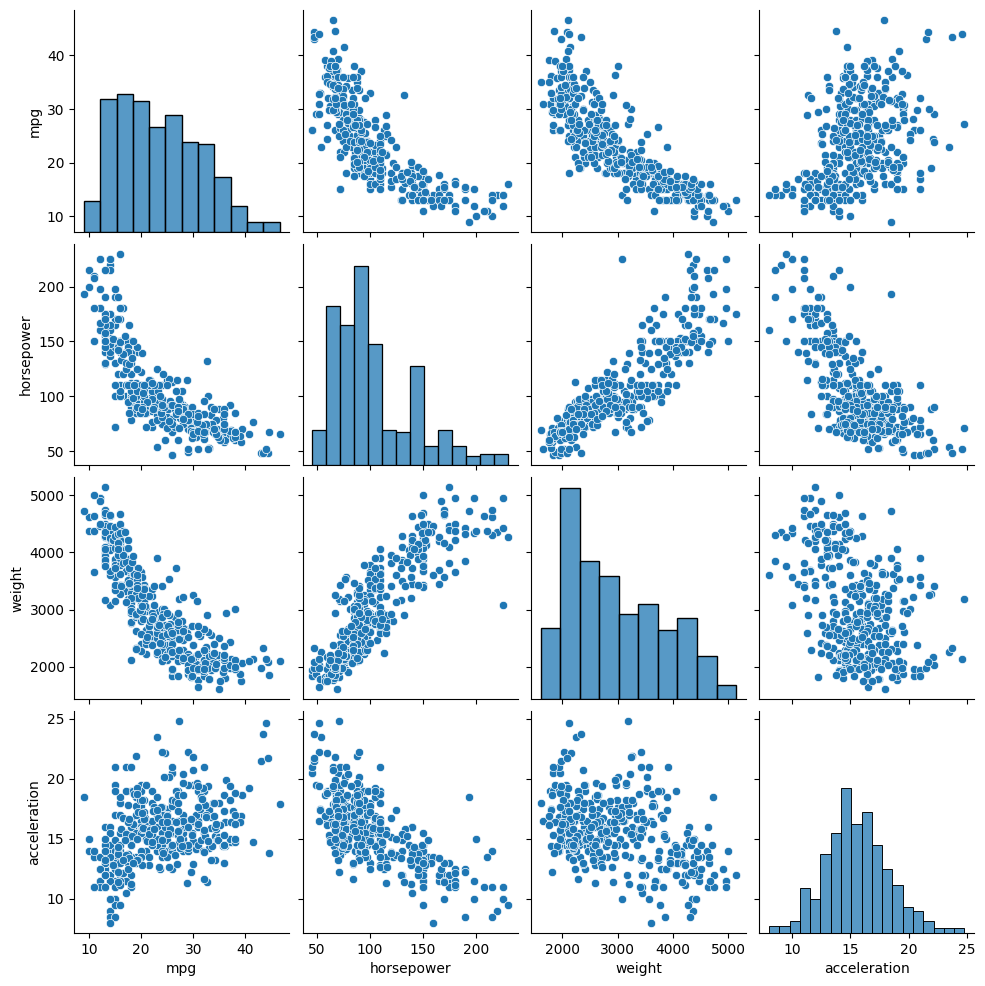

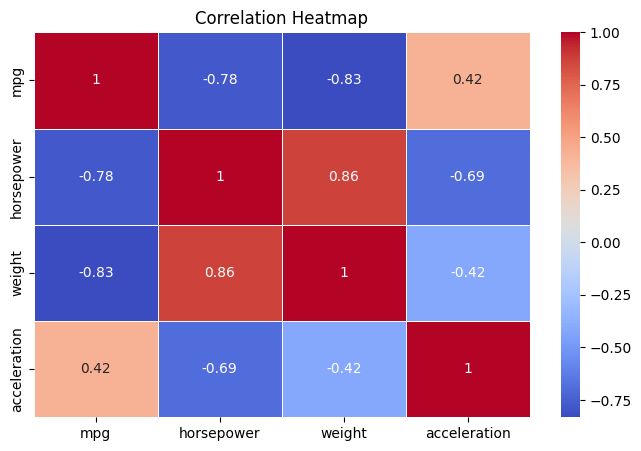

Horsepower Lower Bound: -1.5
Horsepower Upper Bound: 202.5

Shape before outlier removal: (392, 9)
Shape after outlier removal: (382, 9)

Model Performance BEFORE Removing Outliers:
R² Score: 0.5659681822256185
MSE: 22.153237123863413

Model Performance AFTER Removing Outliers:
R² Score: 0.6994698685241629
MSE: 18.55780100636605


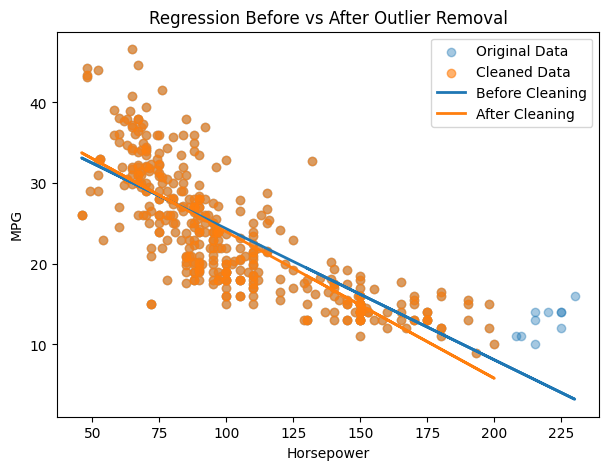

In [5]:
# ----------------------------------------------------
# 1. Import Libraries
# ----------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# ----------------------------------------------------
# 2. Load Dataset
# ----------------------------------------------------
df = pd.read_csv(f"{path}/auto-mpg.csv")

# Replace "?" with NaN
df = df.replace("?", np.nan)

# Convert numeric columns to float
numeric_cols = ['mpg', 'horsepower', 'weight', 'acceleration']
df[numeric_cols] = df[numeric_cols].astype(float)

# Drop rows with missing numeric values
df = df.dropna(subset=numeric_cols)

# Clean column names
df.columns = df.columns.str.strip()

print(df.info())
print(df.head())

# ----------------------------------------------------
# 3. Basic EDA
# ----------------------------------------------------
print("\nMissing Values:")
print(df.isna().sum())

# Distribution of MPG
plt.figure(figsize=(6,4))
sns.histplot(df['mpg'], kde=True)
plt.title("Distribution of MPG")
plt.show()

# Scatter: MPG vs Horsepower
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'], df['mpg'])
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("MPG vs Horsepower")
plt.show()

# Pairplot
sns.pairplot(df[['mpg', 'horsepower', 'weight', 'acceleration']])
plt.show()

# ----------------------------------------------------
# 4. Correlation Heatmap
# ----------------------------------------------------
plt.figure(figsize=(8, 5))
corr = df[['mpg', 'horsepower', 'weight', 'acceleration']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# ----------------------------------------------------
# 5. Outlier Detection (IQR Method)
# ----------------------------------------------------
Q1 = df['horsepower'].quantile(0.25)
Q3 = df['horsepower'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Horsepower Lower Bound:", lower)
print("Horsepower Upper Bound:", upper)

df_clean = df[(df['horsepower'] >= lower) & (df['horsepower'] <= upper)]

print("\nShape before outlier removal:", df.shape)
print("Shape after outlier removal:", df_clean.shape)

# ----------------------------------------------------
# 6. Regression BEFORE outlier removal
# ----------------------------------------------------
X = df[['horsepower']]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_before = LinearRegression()
model_before.fit(X_train, y_train)
pred_before = model_before.predict(X_test)

print("\nModel Performance BEFORE Removing Outliers:")
print("R² Score:", r2_score(y_test, pred_before))
print("MSE:", mean_squared_error(y_test, pred_before))

# ----------------------------------------------------
# 7. Regression AFTER outlier removal
# ----------------------------------------------------
X2 = df_clean[['horsepower']]
y2 = df_clean['mpg']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model_after = LinearRegression()
model_after.fit(X2_train, y2_train)
pred_after = model_after.predict(X2_test)

print("\nModel Performance AFTER Removing Outliers:")
print("R² Score:", r2_score(y2_test, pred_after))
print("MSE:", mean_squared_error(y2_test, pred_after))

# ----------------------------------------------------
# 8. Plot Regression Lines
# ----------------------------------------------------
plt.figure(figsize=(7,5))

# Scatter data
plt.scatter(df['horsepower'], df['mpg'], label="Original Data", alpha=0.4)
plt.scatter(df_clean['horsepower'], df_clean['mpg'], label="Cleaned Data", alpha=0.6)

# Regression lines
plt.plot(df['horsepower'], model_before.predict(X),
         label="Before Cleaning", linewidth=2)

plt.plot(df_clean['horsepower'], model_after.predict(X2),
         label="After Cleaning", linewidth=2)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Regression Before vs After Outlier Removal")
plt.legend()
plt.show()
